# **Machine Learning Final Project**

**Author:** Ayemhenre Isikhuemhen  
**Dataset:** Climate Change Impact on Agriculture  
**Source:** https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture

**File Description:** This notebook studies how climate and agriculture factors relate to crop yield. The goal is to predict crop yield using variables such as temperature, precipitation, CO₂ emissions, extreme weather events, irrigation access, and adaptation strategy. I compare Linear Regression and Random Forest to see how a simple linear model performs against a model that can capture more complex patterns.

---


## Preprocessing

This section prepares the dataset for analysis and modeling. The data is loaded, checked for missing values, cleaned, encoded, and scaled where needed. This makes the dataset easier to work with and keeps the model inputs consistent.


### Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Load dataset
FILE_PATH = (
    r"C:\Users\Owner\Documents\GitHub\ML-Final-Project"
    r"\Final Project\Data\climate_change_impact_on_agriculture_2024.csv"
)

df_raw = pd.read_csv(FILE_PATH)

print("Data Loading Complete")
print(f"  Shape    : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
print(f"  Columns  : {list(df_raw.columns)}")


Data Loading Complete
  Shape    : 10,000 rows × 15 cols
  Columns  : ['Year', 'Country', 'Region', 'Crop_Type', 'Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Crop_Yield_MT_per_HA', 'Extreme_Weather_Events', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Adaptation_Strategies', 'Economic_Impact_Million_USD']


### Data Cleaning

In [2]:
df = df_raw.copy()

# Remove missing rows
null_before = df.isnull().sum().sum()
df.dropna(inplace=True)
null_after = df.isnull().sum().sum()

# Round float columns
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].round(3)

print("Data Cleaning Complete")
print(f"  Null values removed  : {null_before - null_after}")
print(f"  Remaining nulls      : {null_after}")
print(f"  Clean shape          : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  Float cols rounded   : {len(float_cols)}")


Data Cleaning Complete
  Null values removed  : 0
  Remaining nulls      : 0
  Clean shape          : 10,000 rows × 15 cols
  Float cols rounded   : 9


### Data Index

The table below defines the fields in the dataset and the values each field is expected to represent.

| Field | Type | Description | Expected Values |
|---|---|---|---|
| `Year` | int | Calendar year of the observation | 2000 – 2024 |
| `Country` | str | Country where the data was recorded | e.g., India, China, France, Canada |
| `Region` | str | Sub-national region within the country | e.g., West Bengal, North, Prairies |
| `Crop_Type` | str | Type of crop grown | Corn, Wheat, Coffee, Rice, Soybeans, etc. |
| `Average_Temperature_C` | float | Mean annual temperature in Celsius | –5.0 – 40.0 °C |
| `Total_Precipitation_mm` | float | Total annual precipitation in millimeters | 100 – 3000 mm |
| `CO2_Emissions_MT` | float | CO₂ emissions in metric tons per hectare | 0.0 – 50.0 MT |
| `Crop_Yield_MT_per_HA` | float | Target crop yield in metric tons per hectare | 0.0 – 10.0 MT/HA |
| `Extreme_Weather_Events` | int | Number of extreme weather events that year | 0 – 10 |
| `Irrigation_Access_%` | float | Percent of land with irrigation access | 0 – 100% |
| `Pesticide_Use_KG_per_HA` | float | Pesticide use per hectare | 0 – 50 KG/HA |
| `Fertilizer_Use_KG_per_HA` | float | Fertilizer use per hectare | 0 – 100 KG/HA |
| `Soil_Health_Index` | float | Soil quality score | 0 – 100 |
| `Adaptation_Strategies` | str | Strategy used to adjust to climate pressure | e.g., crop rotation, drought-resistant crops |
| `Economic_Impact_Million_USD` | float | Economic impact in millions of USD | 0 – 500 million USD |


### Feature Engineering

In [3]:
df_enc = df.copy()

# Encode categorical fields
cat_cols = ["Country", "Region", "Crop_Type", "Adaptation_Strategies"]
encoders = {}

for col in cat_cols:
    encoder = LabelEncoder()
    df_enc[col] = encoder.fit_transform(df_enc[col].astype(str))
    encoders[col] = encoder

# Define model inputs
TARGET = "Crop_Yield_MT_per_HA"
DROP_COL = [TARGET, "Year"]
FEATURES = [c for c in df_enc.columns if c not in DROP_COL]

X = df_enc[FEATURES]
y = df_enc[TARGET]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for linear regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Feature Engineering Complete")
print(f"  Features             : {len(FEATURES)}")
print(f"  Feature List         : {FEATURES}")
print(f"  Train Size           : {len(X_train):,}")
print(f"  Test Size            : {len(X_test):,}")


Feature Engineering Complete
  Features             : 13
  Feature List         : ['Country', 'Region', 'Crop_Type', 'Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Extreme_Weather_Events', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Adaptation_Strategies', 'Economic_Impact_Million_USD']
  Train Size           : 8,000
  Test Size            : 2,000


---

## General Investigation

Before modeling, this section gives a quick view of the dataset. The goal is to understand how crop yield is distributed, how climate variables relate to yield, and whether any patterns stand out before training the models.


**Visualization 1:** Crop Yield Distribution by Crop Type

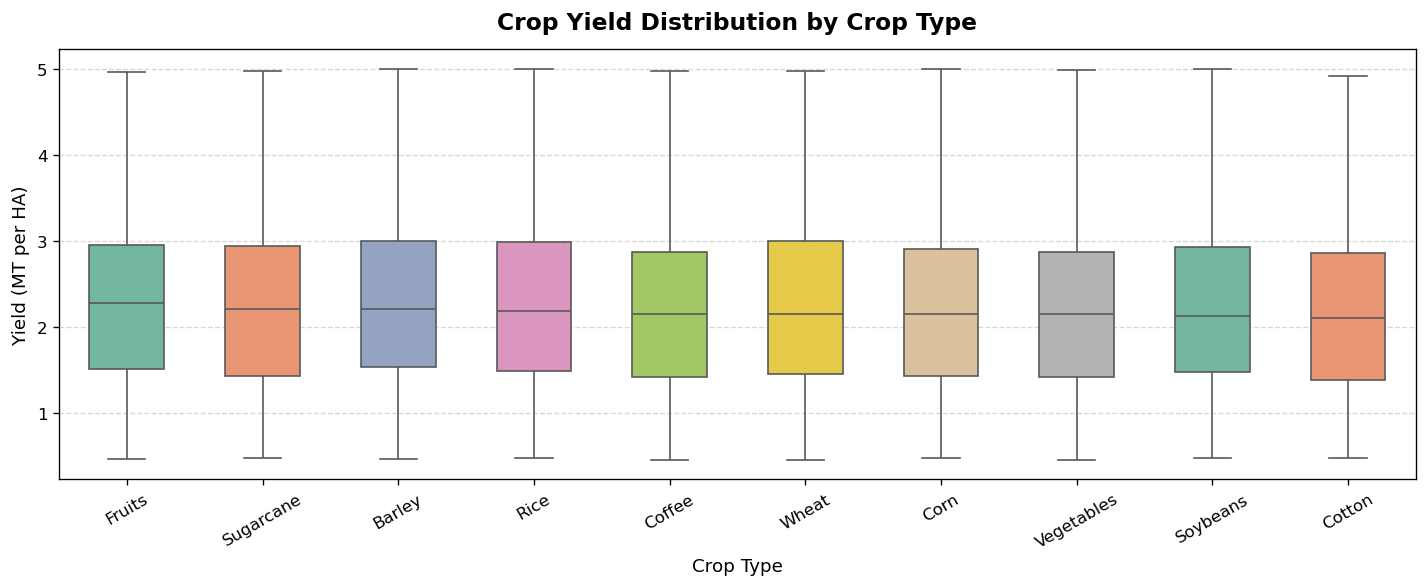

In [4]:
# Plot yield by crop type
fig, ax = plt.subplots(figsize=(12, 5))

order = (
    df.groupby("Crop_Type")[TARGET]
      .median()
      .sort_values(ascending=False)
      .index
)

sns.boxplot(
    data=df, x="Crop_Type", y=TARGET,
    order=order, palette="Set2", width=0.55, ax=ax
)

ax.set_title(
    "Crop Yield Distribution by Crop Type",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_xlabel("Crop Type", fontsize=11)
ax.set_ylabel("Yield (MT per HA)", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Visualization 2:** Climate Variable Correlations with Crop Yield

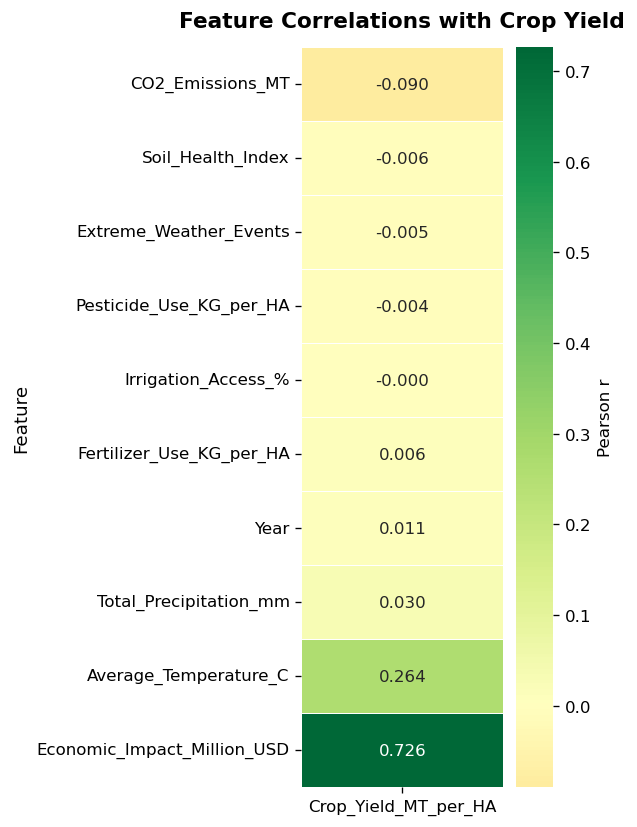

In [5]:
# Check numeric correlations
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
corr = df[num_cols].corr()[[TARGET]].drop(TARGET).sort_values(TARGET)

fig, ax = plt.subplots(figsize=(5, 7))

sns.heatmap(
    corr, annot=True, fmt=".3f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson r"}
)

ax.set_title(
    "Feature Correlations with Crop Yield",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("")
ax.set_ylabel("Feature", fontsize=11)
plt.tight_layout()
plt.show()


**Visualization 3:** Temperature vs Crop Yield Colored by Extreme Weather Events

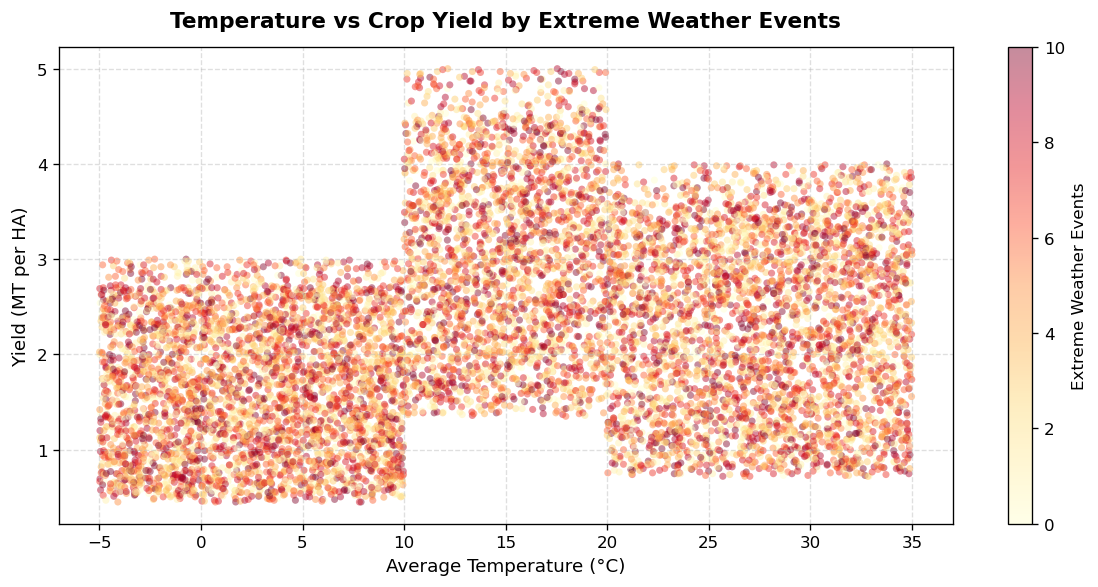

In [6]:
# Plot temperature against yield
fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(
    df["Average_Temperature_C"], df[TARGET],
    c=df["Extreme_Weather_Events"], cmap="YlOrRd",
    alpha=0.45, s=18, edgecolors="none"
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Extreme Weather Events", fontsize=10)

ax.set_title(
    "Temperature vs Crop Yield by Extreme Weather Events",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Average Temperature (°C)", fontsize=11)
ax.set_ylabel("Yield (MT per HA)", fontsize=11)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 4:** Irrigation Access vs Crop Yield by Adaptation Strategy

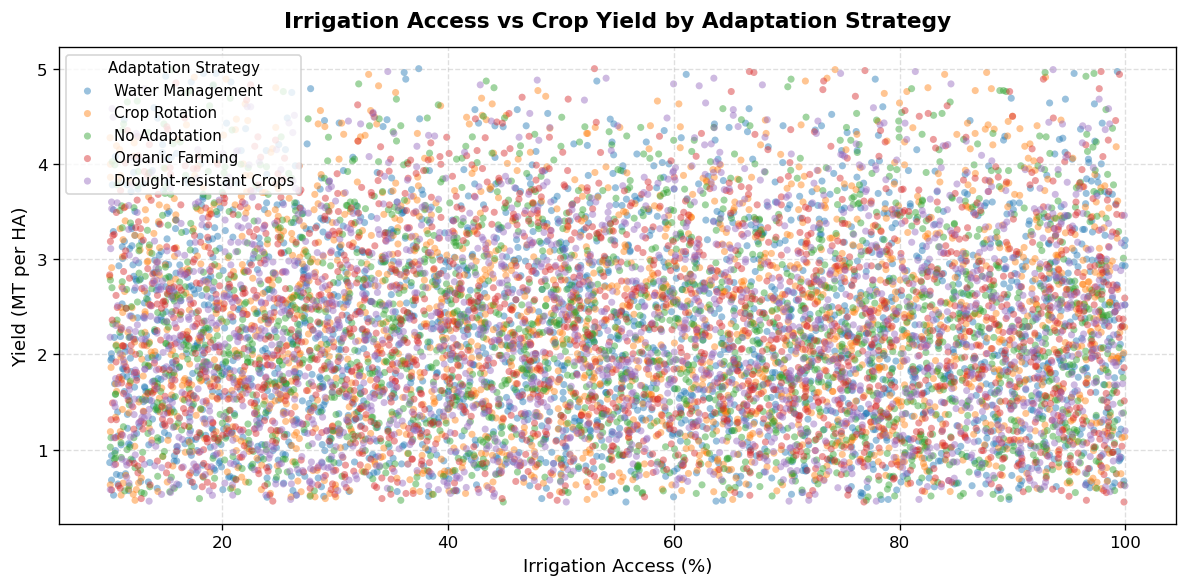

In [7]:
# Compare irrigation and yield
fig, ax = plt.subplots(figsize=(10, 5))

strategies = df["Adaptation_Strategies"].unique()
palette = sns.color_palette("tab10", len(strategies))

for strat, color in zip(strategies, palette):
    subset = df[df["Adaptation_Strategies"] == strat]
    ax.scatter(
        subset["Irrigation_Access_%"], subset[TARGET],
        label=strat, color=color, alpha=0.45,
        s=18, edgecolors="none"
    )

ax.set_title(
    "Irrigation Access vs Crop Yield by Adaptation Strategy",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Irrigation Access (%)", fontsize=11)
ax.set_ylabel("Yield (MT per HA)", fontsize=11)
ax.legend(
    title="Adaptation Strategy", fontsize=9,
    title_fontsize=9, loc="upper left"
)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


---

## Linear Regression

Linear Regression is used first because it gives a clear baseline. It models crop yield as a weighted combination of the input features, which makes the results easier to explain. This is useful for seeing the general direction of each relationship before using a more flexible model.

The model predicts crop yield with this equation:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_n x_n$$

Here, $w_i$ represents the learned weight for each feature and $x_i$ represents the input value. During training, the model tries to reduce the difference between the actual and predicted yield values.


### Setup

In [8]:
# Set up linear regression
lr_model = LinearRegression()

# Report regression metrics
def regression_report(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"  {name}")
    print(f"    RMSE : {rmse:.4f}")
    print(f"    MAE  : {mae:.4f}")
    print(f"    R²   : {r2:.4f}")

    return {
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2": round(r2, 4),
    }

print("Linear Regression Setup Complete")


Linear Regression Setup Complete


### Algorithm

In [9]:
# Train linear regression
lr_model.fit(X_train_sc, y_train)

# Generate predictions
lr_train_pred = lr_model.predict(X_train_sc)
lr_test_pred = lr_model.predict(X_test_sc)

# Store model coefficients
lr_coef_df = (
    pd.DataFrame({"Feature": FEATURES, "Coefficient": lr_model.coef_})
      .sort_values("Coefficient", key=abs, ascending=False)
      .reset_index(drop=True)
)

# Evaluate performance
print("Linear Regression — Performance")
lr_train_metrics = regression_report("Train", y_train, lr_train_pred)
lr_test_metrics = regression_report("Test", y_test, lr_test_pred)

# Save residuals
lr_residuals = y_test - lr_test_pred


Linear Regression — Performance
  Train
    RMSE : 0.6718
    MAE  : 0.5389
    R²   : 0.5402
  Test
    RMSE : 0.6781
    MAE  : 0.5450
    R²   : 0.5644


### Output

**Visualization 1:** Actual vs Predicted Crop Yield

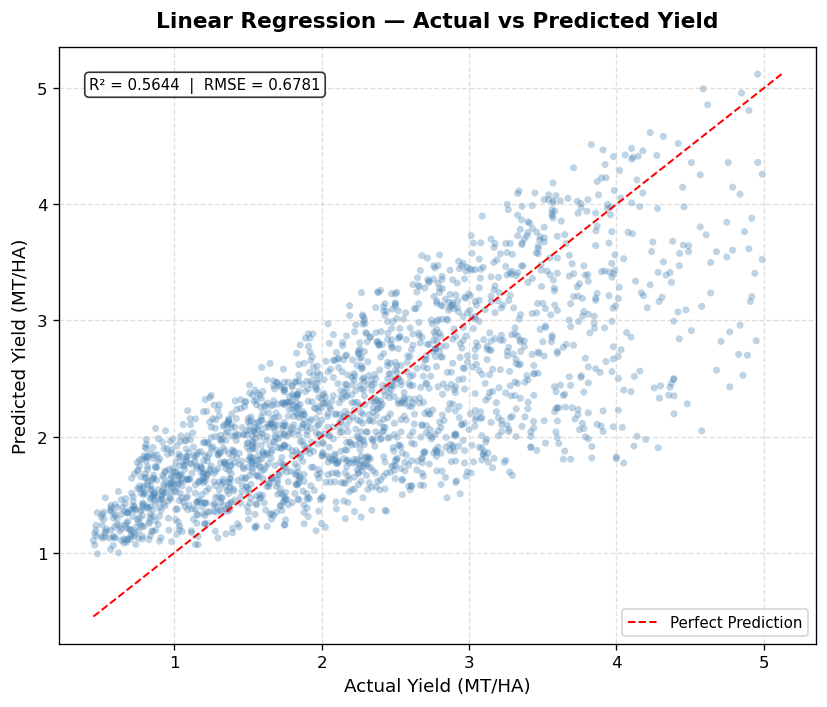

In [10]:
# Plot actual vs predicted values
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    y_test, lr_test_pred, alpha=0.35, s=18,
    color="steelblue", edgecolors="none"
)

lims = [
    min(y_test.min(), lr_test_pred.min()),
    max(y_test.max(), lr_test_pred.max()),
]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect Prediction")

ax.set_title(
    "Linear Regression — Actual vs Predicted Yield",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Actual Yield (MT/HA)", fontsize=11)
ax.set_ylabel("Predicted Yield (MT/HA)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

ax.text(
    0.04, 0.93,
    f"R² = {lr_test_metrics['R2']:.4f}  |  "
    f"RMSE = {lr_test_metrics['RMSE']:.4f}",
    transform=ax.transAxes, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()


**Visualization 2:** Residuals Distribution

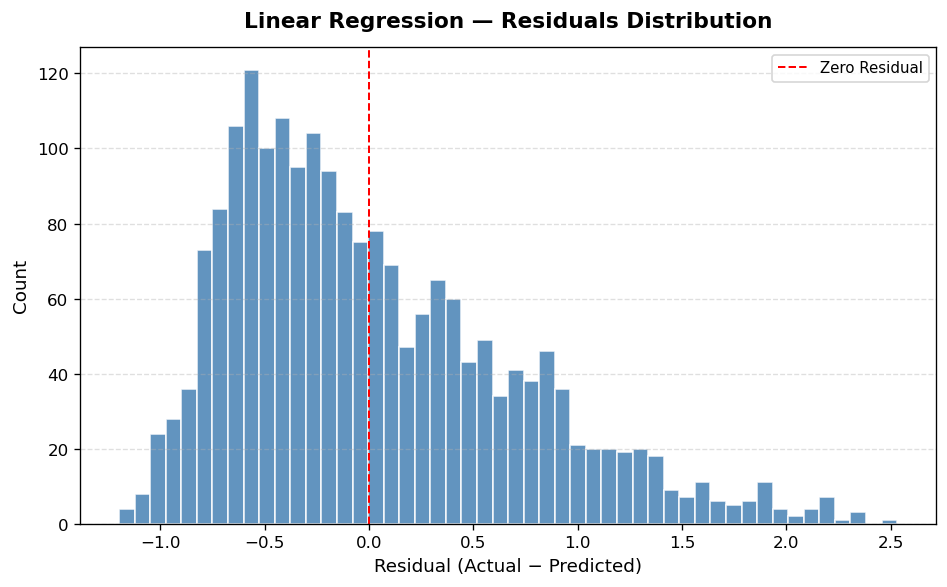

In [11]:
# Plot residual spread
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    lr_residuals, bins=50, color="steelblue",
    edgecolor="white", alpha=0.85
)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero Residual")

ax.set_title(
    "Linear Regression — Residuals Distribution",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Residual (Actual − Predicted)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 3:** Feature Coefficients

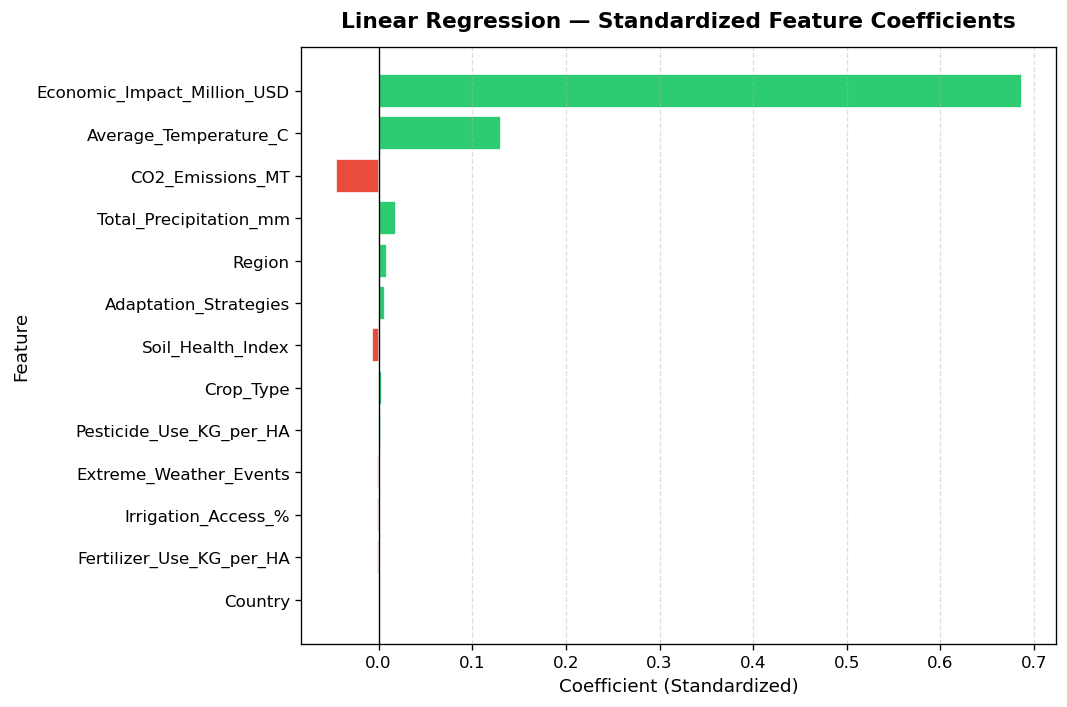

In [12]:
# Plot standardized coefficients
fig, ax = plt.subplots(figsize=(9, 6))

colors = [
    "#2ecc71" if c > 0 else "#e74c3c"
    for c in lr_coef_df["Coefficient"]
]

ax.barh(
    lr_coef_df["Feature"], lr_coef_df["Coefficient"],
    color=colors, edgecolor="white"
)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title(
    "Linear Regression — Standardized Feature Coefficients",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Coefficient (Standardized)", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 4:** Predicted Yield vs Residuals

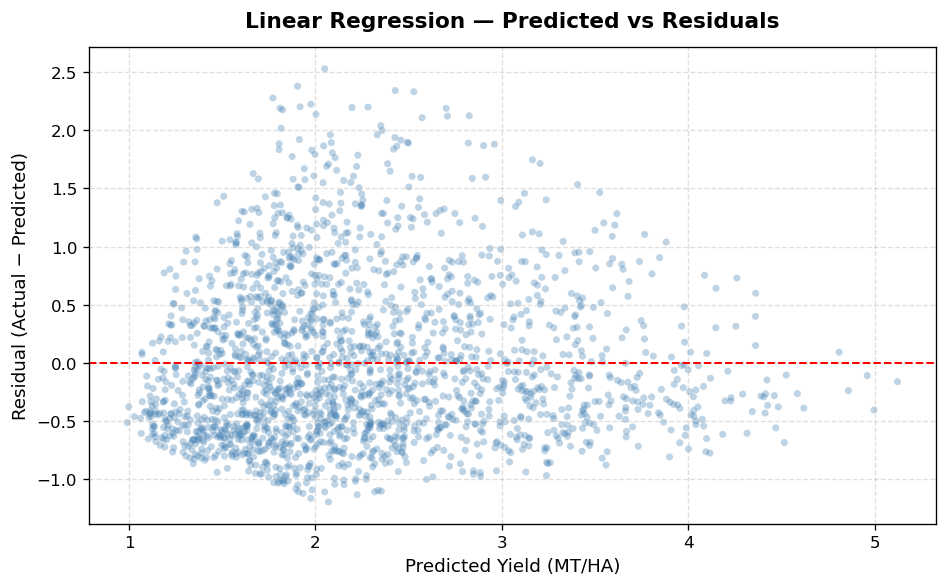

In [13]:
# Check residual patterns
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    lr_test_pred, lr_residuals, alpha=0.35, s=18,
    color="steelblue", edgecolors="none"
)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)

ax.set_title(
    "Linear Regression — Predicted vs Residuals",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Predicted Yield (MT/HA)", fontsize=11)
ax.set_ylabel("Residual (Actual − Predicted)", fontsize=11)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


---

## Random Forest

Random Forest is used as the second model because crop yield may not follow a simple linear pattern. The model builds many decision trees and averages their predictions. This helps capture nonlinear relationships between climate factors and yield while also showing which features are most important.

The Random Forest prediction is the average of many tree predictions:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} h_t(\mathbf{x})$$

Here, each $h_t$ is one decision tree and $T$ is the total number of trees.


### Setup

In [14]:
# Set up random forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Setup Complete")
print(f"  Estimators   : {rf_model.n_estimators}")
print(f"  Max Depth    : {rf_model.max_depth}")
print(f"  Random State : {rf_model.random_state}")


Random Forest Setup Complete
  Estimators   : 200
  Max Depth    : None
  Random State : 42


### Algorithm

In [15]:
# Train random forest
rf_model.fit(X_train, y_train)

# Generate predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Store feature importance
rf_imp_df = (
    pd.DataFrame({"Feature": FEATURES, "Importance": rf_model.feature_importances_})
      .sort_values("Importance", ascending=False)
      .reset_index(drop=True)
)

# Evaluate performance
print("Random Forest — Performance")
rf_train_metrics = regression_report("Train", y_train, rf_train_pred)
rf_test_metrics = regression_report("Test", y_test, rf_test_pred)

# Save residuals
rf_residuals = y_test - rf_test_pred


Random Forest — Performance
  Train
    RMSE : 0.2304
    MAE  : 0.1830
    R²   : 0.9459
  Test
    RMSE : 0.6286
    MAE  : 0.5063
    R²   : 0.6256


### Output

**Visualization 1:** Actual vs Predicted Crop Yield

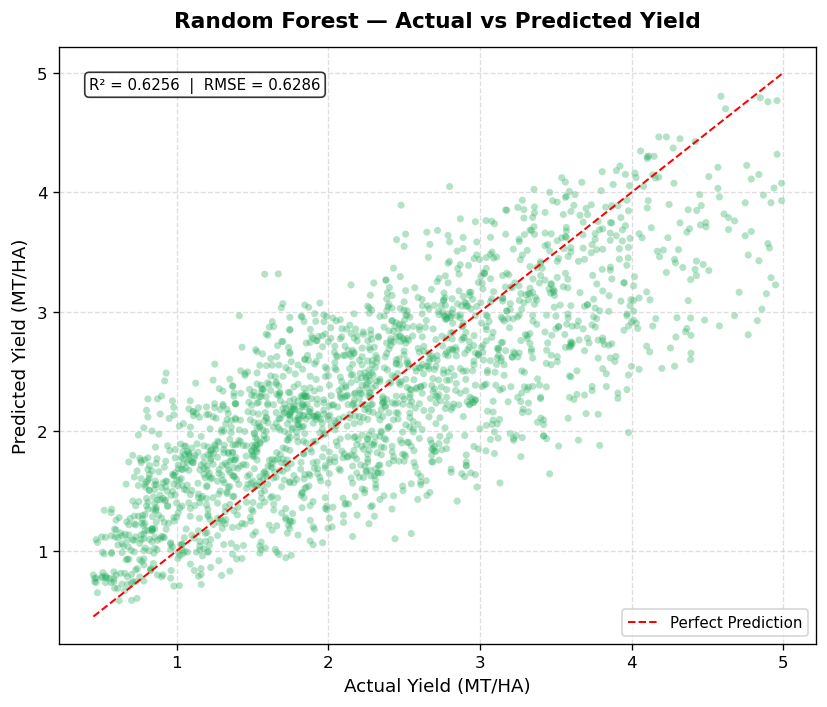

In [16]:
# Plot actual vs predicted values
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    y_test, rf_test_pred, alpha=0.35, s=18,
    color="#27ae60", edgecolors="none"
)

lims = [
    min(y_test.min(), rf_test_pred.min()),
    max(y_test.max(), rf_test_pred.max()),
]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect Prediction")

ax.set_title(
    "Random Forest — Actual vs Predicted Yield",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Actual Yield (MT/HA)", fontsize=11)
ax.set_ylabel("Predicted Yield (MT/HA)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

ax.text(
    0.04, 0.93,
    f"R² = {rf_test_metrics['R2']:.4f}  |  "
    f"RMSE = {rf_test_metrics['RMSE']:.4f}",
    transform=ax.transAxes, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()


**Visualization 2:** Feature Importances

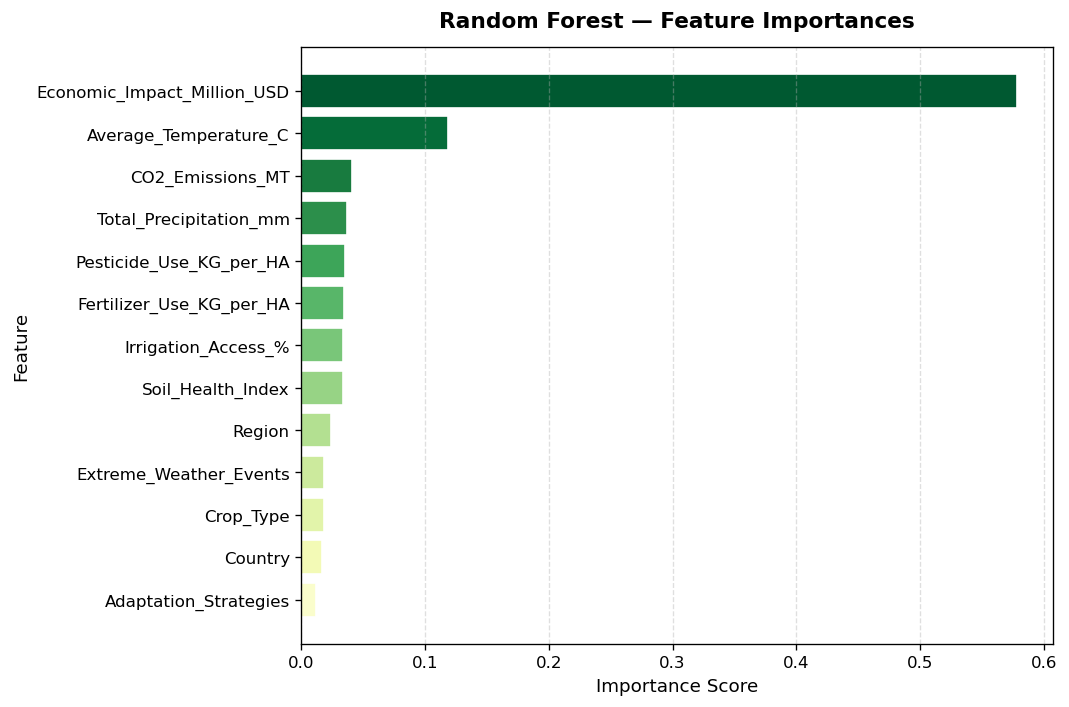

In [17]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(9, 6))

palette = sns.color_palette("YlGn_r", len(rf_imp_df))
ax.barh(
    rf_imp_df["Feature"], rf_imp_df["Importance"],
    color=palette, edgecolor="white"
)

ax.set_title(
    "Random Forest — Feature Importances",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 3:** Residuals Distribution

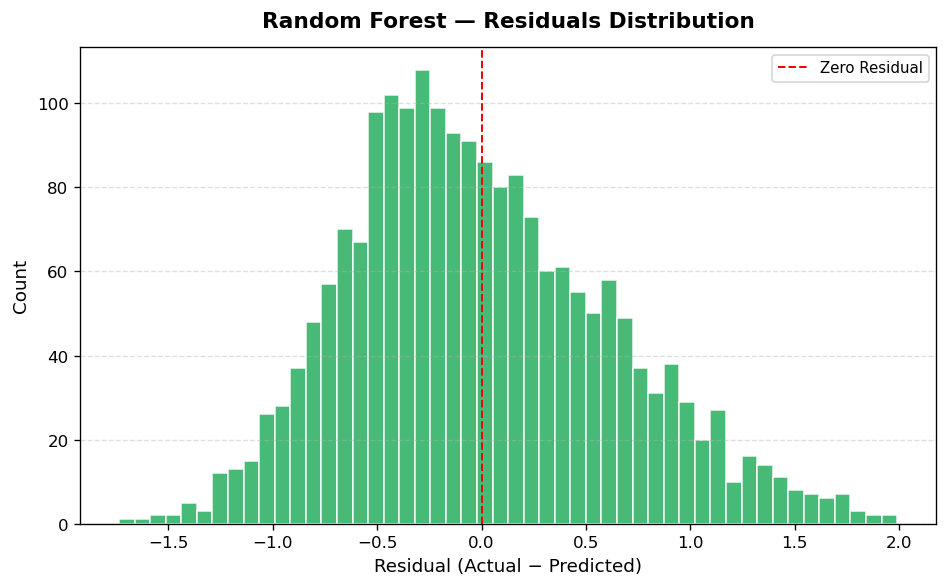

In [18]:
# Plot residual spread
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    rf_residuals, bins=50, color="#27ae60",
    edgecolor="white", alpha=0.85
)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero Residual")

ax.set_title(
    "Random Forest — Residuals Distribution",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Residual (Actual − Predicted)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 4:** Predicted Yield vs Residuals

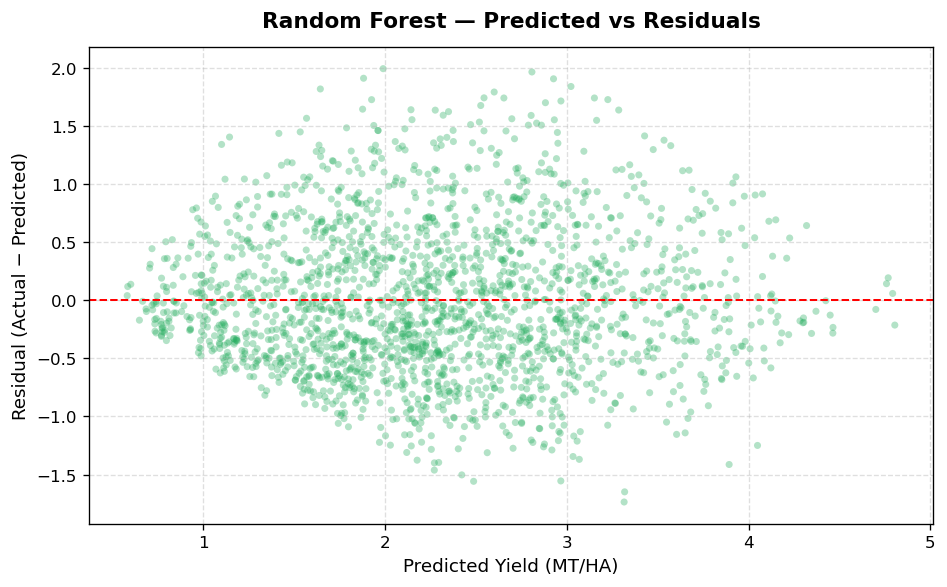

In [19]:
# Check residual patterns
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    rf_test_pred, rf_residuals, alpha=0.35, s=18,
    color="#27ae60", edgecolors="none"
)
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)

ax.set_title(
    "Random Forest — Predicted vs Residuals",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Predicted Yield (MT/HA)", fontsize=11)
ax.set_ylabel("Residual (Actual − Predicted)", fontsize=11)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


---

## Model Comparison

This section compares Linear Regression and Random Forest side by side. The goal is to see whether the added complexity of Random Forest improves prediction quality compared with the simpler baseline model.


**Visualization 1:** Side-by-Side Metric Comparison

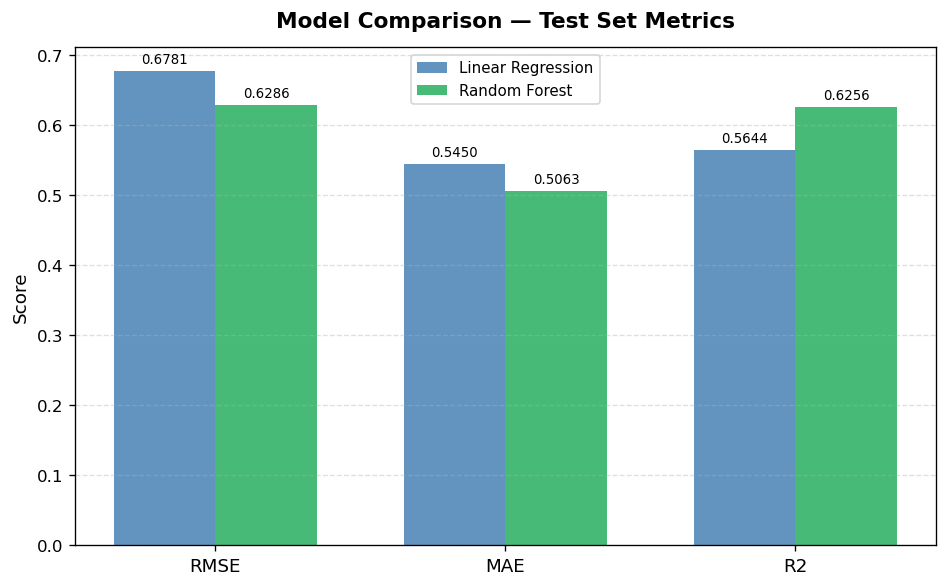

In [20]:
# Compare model metrics
metrics = ["RMSE", "MAE", "R2"]
lr_vals = [lr_test_metrics[m] for m in metrics]
rf_vals = [rf_test_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_lr = ax.bar(
    x - width / 2, lr_vals, width,
    label="Linear Regression", color="steelblue", alpha=0.85
)
bars_rf = ax.bar(
    x + width / 2, rf_vals, width,
    label="Random Forest", color="#27ae60", alpha=0.85
)

ax.bar_label(bars_lr, fmt="%.4f", fontsize=8, padding=3)
ax.bar_label(bars_rf, fmt="%.4f", fontsize=8, padding=3)

ax.set_title(
    "Model Comparison — Test Set Metrics",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 2:** Actual vs Predicted — Both Models Overlaid

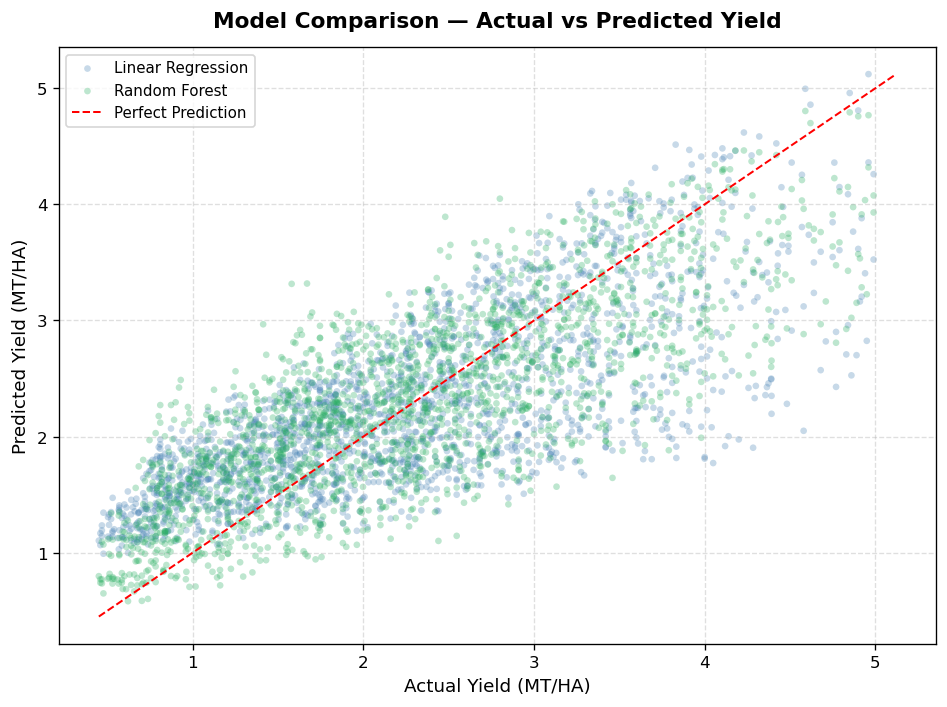

In [21]:
# Compare prediction behavior
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    y_test, lr_test_pred, alpha=0.3, s=16,
    color="steelblue", label="Linear Regression", edgecolors="none"
)
ax.scatter(
    y_test, rf_test_pred, alpha=0.3, s=16,
    color="#27ae60", label="Random Forest", edgecolors="none"
)

lims = [
    min(y_test.min(), lr_test_pred.min(), rf_test_pred.min()),
    max(y_test.max(), lr_test_pred.max(), rf_test_pred.max()),
]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect Prediction")

ax.set_title(
    "Model Comparison — Actual vs Predicted Yield",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Actual Yield (MT/HA)", fontsize=11)
ax.set_ylabel("Predicted Yield (MT/HA)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Visualization 3:** Residuals Distribution — Both Models Overlaid

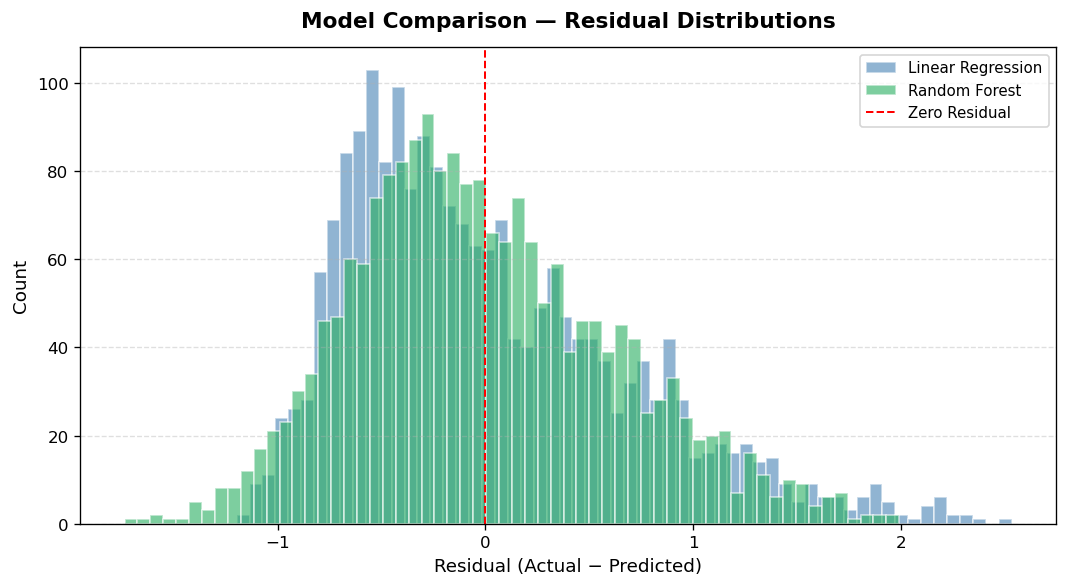

In [22]:
# Compare residual distributions
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    lr_residuals, bins=60, color="steelblue", alpha=0.6,
    label="Linear Regression", edgecolor="white"
)
ax.hist(
    rf_residuals, bins=60, color="#27ae60", alpha=0.6,
    label="Random Forest", edgecolor="white"
)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero Residual")

ax.set_title(
    "Model Comparison — Residual Distributions",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Residual (Actual − Predicted)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


---

## Acknowledgments


`Acknowledgement:`  
This is the work of Ayemhenre Isikhuemhen, using references and code snippets from personal data mining projects, and documentation for the libraries.

## References


`References:`
- https://numpy.org/doc/stable/
- https://pandas.pydata.org/docs/
- https://scikit-learn.org/stable/
- https://matplotlib.org/stable/
- https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture

